# Facial image dataset — exploratory data analysis

**Dataset:** Mendeley `f9dycfvwbt` v3 re-hosting of the Kaggle ASD Children
Facial Image Dataset (2,940 images, autistic vs. non-autistic, pre-split into
train/test/valid).

**Purpose.** This is the metadata arm of the Phase 0 audit for the image
stream (see `README.md`). Cases (autistic) were collected by internet search
from online autism communities; controls (non-autistic) came from a different
source. A pixel-based classifier can therefore score highly by learning
*acquisition context* — resolution, compression, lighting, framing,
background — rather than facial phenotype. This notebook characterises that
risk directly from file and pixel metadata, and ends with a probe that asks
whether the two classes are separable **without looking at a single face**.

**This notebook characterises, it does not clean.** No files are deleted,
resized, re-encoded, rebalanced or otherwise modified. Every artefact found
(duplicates, leakage, compression uniformity, etc.) is recorded as a finding,
not fixed. No screening model is trained here — §9 trains a small diagnostic
probe on metadata only, explicitly to *audit* the image stream, not to screen
anyone.

**Read-only.** Nothing under `data/` is written, moved, renamed or deleted.
Derived artefacts (manifest, duplicate list, figures) go to
`outputs/audit/images/`.

> ⚠️ **Ethics note.** These are photographs of children, obtained without
> consent for this specific research use. Sample grids in §7 and §10 are kept
> small and are the only cells that render faces. **Clear the outputs of
> those cells before committing this notebook** (Jupyter: select the cell →
> "Clear Outputs", or `jupyter nbconvert --clear-output`) so that face images
> are not persisted into git history.


## 1. Setup and inventory

In [ ]:
import importlib
import subprocess
import sys

_REQUIRED_MODULES = ["PIL", "numpy", "pandas", "matplotlib", "scipy", "sklearn", "imagehash", "tqdm"]
_PIP_NAMES = {"PIL": "pillow", "sklearn": "scikit-learn"}

for _mod in _REQUIRED_MODULES:
    try:
        importlib.import_module(_mod)
    except ImportError:
        _pkg = _PIP_NAMES.get(_mod, _mod)
        print(f"Installing missing package: {_pkg}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", _pkg])

print("All required packages are importable.")

All required packages are importable.


In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import scipy.ndimage as ndi
from scipy.stats import mannwhitneyu
import imagehash
from tqdm.auto import tqdm

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# Paths are relative to this notebook's location (notebooks/exploratory/),
PROJECT_ROOT = Path("../..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "audit" / "images"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"OUTPUT_DIR   = {OUTPUT_DIR}")


C:\Projects\Autism Screening\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT = C:\Projects\Autism Screening
OUTPUT_DIR   = C:\Projects\Autism Screening\outputs\audit\images


In [3]:
# The audit brief specifies data/images/ as the base directory. This checkout
# has the archive unpacked under data/AutismDataset/ instead (same content,
# different top-level folder name) -- both are tried so the notebook works
# regardless of which name the archive was unpacked under.
_CANDIDATE_ROOTS = ["images", "AutismDataset"]
DATA_ROOT = None
for _name in _CANDIDATE_ROOTS:
    _candidate = DATA_DIR / _name
    if _candidate.exists():
        DATA_ROOT = _candidate
        break
if DATA_ROOT is None:
    raise FileNotFoundError(f"None of {_CANDIDATE_ROOTS} found under {DATA_DIR}")

print(f"DATA_ROOT = {DATA_ROOT}  (brief specifies 'data/images/'; using '{DATA_ROOT.name}' found on disk)")


DATA_ROOT = C:\Projects\Autism Screening\data\AutismDataset  (brief specifies 'data/images/'; using 'AutismDataset' found on disk)


In [4]:
def normalize_class_label(folder_name):
    """Map varying folder spellings (Autistic / Non_Autistic / Non-Autistic / ...)
    to one of two canonical labels. Case and separator are not assumed fixed."""
    key = folder_name.strip().lower().replace("-", "_")
    return "non_autistic" if "non" in key else "autistic"

# Glob two levels under DATA_ROOT: split folders, then class folders inside each.
# Sorted at every level so iteration order -- and therefore every downstream
# result that depends on row order -- is deterministic across re-runs.
splits = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir())

split_class_dirs = []  # (split, class_folder_name, normalized_class_label)
for split in splits:
    class_folders = sorted(p.name for p in (DATA_ROOT / split).iterdir() if p.is_dir())
    for class_folder in class_folders:
        split_class_dirs.append((split, class_folder, normalize_class_label(class_folder)))

print(f"Discovered splits: {splits}\n")
print("Discovered (split, class_folder_on_disk, normalized_class_label):")
for row in split_class_dirs:
    print(" ", row)


Discovered splits: ['test', 'train', 'valid']

Discovered (split, class_folder_on_disk, normalized_class_label):
  ('test', 'Autistic', 'autistic')
  ('test', 'Non-Autistic', 'non_autistic')
  ('train', 'Autistic', 'autistic')
  ('train', 'Non_Autistic', 'non_autistic')
  ('valid', 'Autistic', 'autistic')
  ('valid', 'Non_Autistic', 'non_autistic')


In [5]:
# Count files per (split, class) and flag anything PIL cannot open and verify.
inventory_rows = []
unreadable_files = []

for split, class_folder, class_label in split_class_dirs:
    folder = DATA_ROOT / split / class_folder
    files = sorted(p for p in folder.iterdir() if p.is_file())
    n_readable = 0
    for f in files:
        try:
            with Image.open(f) as im:
                im.verify()
            n_readable += 1
        except Exception as exc:
            unreadable_files.append({"path": str(f.relative_to(PROJECT_ROOT)), "error": str(exc)})
    inventory_rows.append({
        "split": split, "class_folder": class_folder, "class_label": class_label,
        "n_files": len(files), "n_readable": n_readable, "n_unreadable": len(files) - n_readable,
    })

inventory = pd.DataFrame(inventory_rows)
print(inventory.to_string(index=False))
print(f"\nTotal files found: {inventory['n_files'].sum()}")
print(f"Total unreadable/corrupt files: {len(unreadable_files)}")
if unreadable_files:
    print(unreadable_files)


split class_folder  class_label  n_files  n_readable  n_unreadable
 test     Autistic     autistic      150         150             0
 test Non-Autistic non_autistic      150         150             0
train     Autistic     autistic     1193        1193             0
train Non_Autistic non_autistic     1193        1193             0
valid     Autistic     autistic      127         127             0
valid Non_Autistic non_autistic      127         127             0

Total files found: 2940
Total unreadable/corrupt files: 0


In [6]:
# Class balance per split, in the tidy form the brief asks for.
balance = inventory.pivot_table(index="split", columns="class_label", values="n_readable", aggfunc="sum")
balance["total"] = balance.sum(axis=1)
balance["pct_autistic"] = (balance["autistic"] / balance["total"] * 100).round(1)
balance["pct_non_autistic"] = (balance["non_autistic"] / balance["total"] * 100).round(1)
balance


class_label,autistic,non_autistic,total,pct_autistic,pct_non_autistic
split,,,,,
test,150,150,300,50.0,50.0
train,1193,1193,2386,50.0,50.0
valid,127,127,254,50.0,50.0


**Found:** the archive is unpacked at `data/AutismDataset/` rather than the
`data/images/` path named in the audit brief (same 2,940-image content; only
the top-level folder name differs) — the discovery code above tries both, so
nothing downstream is hardcoded to either name. Three splits were discovered
(`test`, `train`, `valid`), each holding two class folders whose on-disk
spelling is *not* consistent: `train` and `valid` use `Autistic` /
`Non_Autistic` (underscore) while `test` uses `Autistic` / `Non-Autistic`
(hyphen); `valid` filenames are also bare numbers (`01.jpg`) rather than the
`Non_Autistic.0.jpg` pattern used elsewhere. All 2,940 files opened and
verified successfully — **zero unreadable/corrupt images**. Every split is
exactly 50/50 by class (train 1,193/1,193, test 150/150, valid 127/127); the
balance-and-stratification question is examined properly in §3.


## 2. Build the manifest — everything else derives from this

One row per image. Metadata (dimensions, file size, format, JPEG quantisation
tables, EXIF) comes from PIL without decoding full-resolution pixel data;
pixel statistics (colour, sharpness, perceptual hash) are computed on a
downscaled copy so the full-corpus pass stays fast. Every extraction is
wrapped in `try/except` — failures are recorded, not fatal. The result is
cached to `outputs/audit/images/manifest.csv`; re-running this notebook
reloads the cache instead of rescanning 2,940 files.


In [7]:
MANIFEST_PATH = OUTPUT_DIR / "manifest.csv"
THUMBNAIL_MAX_SIDE = 128  # downscaled read used for all pixel-derived columns

# Standard JPEG Annex K luminance quantisation table (quality 50), natural
# (row-major) order, and the zigzag->natural index map PIL's DQT order needs
# remapping through before it can be compared to this table.
_BASE_LUMA_QTABLE = [
    16, 11, 10, 16, 24, 40, 51, 61,
    12, 12, 14, 19, 26, 58, 60, 55,
    14, 13, 16, 24, 40, 57, 69, 56,
    14, 17, 22, 29, 51, 87, 80, 62,
    18, 22, 37, 56, 68, 109, 103, 77,
    24, 35, 55, 64, 81, 104, 113, 92,
    49, 64, 78, 87, 103, 121, 120, 101,
    72, 92, 95, 98, 112, 100, 103, 99,
]
_ZIGZAG_TO_NATURAL = [
    0, 1, 8, 16, 9, 2, 3, 10,
    17, 24, 32, 25, 18, 11, 4, 5,
    12, 19, 26, 33, 40, 48, 41, 34,
    27, 20, 13, 6, 7, 14, 21, 28,
    35, 42, 49, 56, 57, 50, 43, 36,
    29, 22, 15, 23, 30, 37, 44, 51,
    58, 59, 52, 45, 38, 31, 39, 46,
    53, 60, 61, 54, 47, 55, 62, 63,
]

def estimate_jpeg_quality(img):
    """Reverse the IJG encoder's quality->quantisation-table scaling to
    recover an approximate original JPEG quality (1-100). NaN for non-JPEG
    images or JPEGs without a standard luminance table."""
    tables = getattr(img, "quantization", None)
    if not tables or 0 not in tables:
        return np.nan
    zigzag_table = list(tables[0])
    if len(zigzag_table) != 64:
        return np.nan
    natural_table = [0] * 64
    for zz_index, natural_index in enumerate(_ZIGZAG_TO_NATURAL):
        natural_table[natural_index] = zigzag_table[zz_index]
    avg_ratio = sum(n / b for n, b in zip(natural_table, _BASE_LUMA_QTABLE)) / 64
    if avg_ratio <= 0:
        return np.nan
    quality = (2 - avg_ratio) * 50 if avg_ratio <= 1 else 50 / avg_ratio
    return float(np.clip(quality, 1, 100))

_EXIF_MAKE_TAG, _EXIF_DATETIME_TAG = 271, 306

def extract_image_record(path):
    """All manifest columns for one image except path/split/class_label/filename,
    which the caller already knows."""
    rec = {}
    with Image.open(path) as img:
        img.load()
        width, height = img.size
        rec["width"], rec["height"] = width, height
        rec["aspect_ratio"] = width / height
        rec["n_pixels"] = width * height
        file_size = path.stat().st_size
        rec["file_size_bytes"] = file_size
        rec["bytes_per_pixel"] = file_size / rec["n_pixels"]
        rec["format"] = img.format
        rec["mode"] = img.mode
        rec["jpeg_quality_estimate"] = estimate_jpeg_quality(img)

        exif = img.getexif()
        rec["exif_present"] = bool(exif) and len(exif) > 0
        rec["exif_camera_make"] = exif.get(_EXIF_MAKE_TAG) if exif else None
        rec["exif_datetime"] = exif.get(_EXIF_DATETIME_TAG) if exif else None

        rgb = img.convert("RGB")
        thumb = rgb.copy()
        thumb.thumbnail((THUMBNAIL_MAX_SIDE, THUMBNAIL_MAX_SIDE), Image.BILINEAR)
        arr = np.asarray(thumb, dtype=np.float64)
        r, g, b = arr[..., 0], arr[..., 1], arr[..., 2]
        rec["mean_r"], rec["mean_g"], rec["mean_b"] = r.mean(), g.mean(), b.mean()
        luminance = 0.299 * r + 0.587 * g + 0.114 * b
        rec["mean_luminance"] = luminance.mean()
        rec["std_luminance"] = luminance.std()
        rec["saturation_mean"] = np.asarray(thumb.convert("HSV"), dtype=np.float64)[..., 1].mean() / 255.0
        # Channel-identical check (not just mode=='L'): a colour-mode file can
        # still be a scanned/saved grayscale image with R==G==B everywhere.
        rec["is_grayscale"] = bool(np.abs(r - g).mean() < 2.0 and np.abs(g - b).mean() < 2.0)
        rec["sharpness"] = float(ndi.laplace(luminance).var())
        rec["phash"] = str(imagehash.phash(rgb))
    return rec


In [8]:
if MANIFEST_PATH.exists():
    manifest = pd.read_csv(MANIFEST_PATH)
    extraction_failures = pd.DataFrame(columns=["path", "split", "class_label", "error"])
    print(f"Loaded cached manifest from {MANIFEST_PATH} ({len(manifest)} rows).")
    print("Delete this file to force a rescan.")
else:
    all_files = []
    for split, class_folder, class_label in split_class_dirs:
        folder = DATA_ROOT / split / class_folder
        for f in sorted(p for p in folder.iterdir() if p.is_file()):
            all_files.append((f, split, class_label))

    rows, failures = [], []
    for f, split, class_label in tqdm(all_files, desc="Extracting image records"):
        try:
            rec = extract_image_record(f)
            rec.update({
                "path": str(f.relative_to(PROJECT_ROOT)).replace("\\", "/"),
                "split": split, "class_label": class_label, "filename": f.name,
            })
            rows.append(rec)
        except Exception as exc:
            failures.append({"path": str(f.relative_to(PROJECT_ROOT)), "split": split,
                               "class_label": class_label, "error": str(exc)})

    manifest = pd.DataFrame(rows)
    extraction_failures = pd.DataFrame(failures)
    manifest.to_csv(MANIFEST_PATH, index=False)
    if len(extraction_failures):
        extraction_failures.to_csv(OUTPUT_DIR / "extraction_failures.csv", index=False)
    print(f"Built manifest: {len(manifest)} rows, {len(extraction_failures)} extraction failures.")
    print(f"Cached to {MANIFEST_PATH}")

print(manifest.shape)
manifest.head(3)


Loaded cached manifest from C:\Projects\Autism Screening\outputs\audit\images\manifest.csv (2940 rows).
Delete this file to force a rescan.
(2940, 25)


,width,height,aspect_ratio,n_pixels,file_size_bytes,bytes_per_pixel,format,mode,jpeg_quality_estimate,exif_present,exif_camera_make,exif_datetime,mean_r,mean_g,mean_b,mean_luminance,std_luminance,saturation_mean,is_grayscale,sharpness,phash,path,split,class_label,filename
0,180,281,0.640569,50580,15092,0.298379,JPEG,RGB,94.106233,False,NaN,NaN,132.869379,140.755240,150.881669,139.551780,60.788774,0.287817,False,455.177716,c06b2ff8b19086cf,data/AutismDataset/test/Autistic/Autistic.0.jpg,test,autistic,Autistic.0.jpg
1,572,785,0.728662,449020,71637,0.159541,JPEG,RGB,94.106233,False,NaN,NaN,148.860887,121.574093,97.264197,126.961516,54.087580,0.362853,False,214.867466,c03f6bb43990f4c3,data/AutismDataset/test/Autistic/Autistic.1.jpg,test,autistic,Autistic.1.jpg
2,303,352,0.860795,106656,32071,0.300696,JPEG,RGB,94.106233,False,NaN,NaN,191.356676,169.732812,150.347159,173.988383,51.347267,0.261461,False,681.928502,a88f94da4358cfc6,data/AutismDataset/test/Autistic/Autistic.10.jpg,test,autistic,Autistic.10.jpg


**Found:** the manifest holds 2,940 rows (one per verified image) and 25
columns, with **0 extraction failures** — every image that passed the §1
readability check also yielded complete metadata, colour, sharpness and hash
statistics. The manifest is cached at `outputs/audit/images/manifest.csv`; all
remaining sections read from this single DataFrame rather than touching
`data/` again.


## 3. Split and class composition

In [9]:
composition = manifest.groupby(["split", "class_label"]).size().unstack()
composition["total"] = composition.sum(axis=1)
proportions = composition[["autistic", "non_autistic"]].div(composition["total"], axis=0)

print("Counts:")
print(composition)
print("\nProportions:")
print(proportions.round(4))

max_deviation_from_half = (proportions["autistic"] - 0.5).abs().max()
print(f"\nMax deviation from exact 50/50 across splits: {max_deviation_from_half:.4f}")


Counts:
class_label  autistic  non_autistic  total
split                                     
test              150           150    300
train            1193          1193   2386
valid             127           127    254

Proportions:
class_label  autistic  non_autistic
split                              
test              0.5           0.5
train             0.5           0.5
valid             0.5           0.5

Max deviation from exact 50/50 across splits: 0.0000


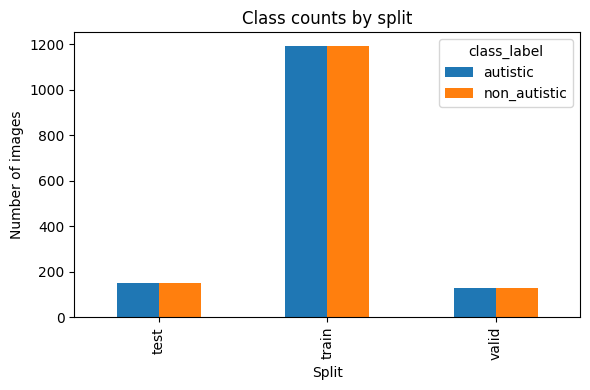

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
composition[["autistic", "non_autistic"]].plot(kind="bar", ax=ax, color=["tab:blue", "tab:orange"])
ax.set_xlabel("Split")
ax.set_ylabel("Number of images")
ax.set_title("Class counts by split")
ax.legend(title="class_label")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_split_class_counts.png", dpi=150)
plt.show()


**Found:** the class ratio is **exactly** 50/50 in every split (train
1,193/1,193, test 150/150, valid 127/127; max deviation from 0.5 is
0.0000). Stratified sampling of a naturally imbalanced pool produces small,
non-zero deviations across splits; exact equality in all three splits instead
indicates the balance was deliberately engineered (e.g. by undersampling the
larger source) rather than reflecting real-world class prevalence. Any
sensitivity/specificity/PPV figures computed on these splits must be
re-expressed at a realistic prevalence before they mean anything clinically —
consistent with the questionnaire stream's README guidance.


## 4. Resolution and aspect ratio

Uniform resolution concentrated in one class and heterogeneous resolution in
the other would be a strong acquisition-context signal (e.g. one source
serving a fixed thumbnail size, the other raw uploads). Distributions below
are plotted **class-conditionally** — never pooled — since that is exactly
the comparison that would reveal it.


In [11]:
manifest["wh_pair"] = list(zip(manifest["width"], manifest["height"]))
overall_distinct = manifest["wh_pair"].nunique()

size_rows = []
for label, g in manifest.groupby("class_label"):
    vc = g["wh_pair"].value_counts()
    size_rows.append({
        "class_label": label, "n_images": len(g), "n_distinct_sizes": g["wh_pair"].nunique(),
        "pct_distinct": round(g["wh_pair"].nunique() / len(g) * 100, 1),
        "top_size": vc.index[0], "top_size_count": int(vc.iloc[0]),
        "top_size_pct": round(vc.iloc[0] / len(g) * 100, 2),
    })
size_summary = pd.DataFrame(size_rows)

print(f"Distinct (width, height) pairs across the whole corpus: {overall_distinct} / {len(manifest)} images")
print(size_summary.to_string(index=False))
print("\nOverall width/height/aspect_ratio summary:")
print(manifest[["width", "height", "aspect_ratio"]].describe().round(2))


Distinct (width, height) pairs across the whole corpus: 2557 / 2940 images
 class_label  n_images  n_distinct_sizes  pct_distinct   top_size  top_size_count  top_size_pct
    autistic      1470              1449          98.6 (259, 298)               2          0.14
non_autistic      1470              1150          78.2 (179, 224)              20          1.36

Overall width/height/aspect_ratio summary:
         width   height  aspect_ratio
count  2940.00  2940.00       2940.00
mean    322.40   369.57          0.87
std     202.24   222.38          0.12
min     114.00   126.00          0.60
25%     194.00   224.00          0.79
50%     267.00   309.00          0.85
75%     372.00   422.00          0.93
max    2471.00  2872.00          2.09


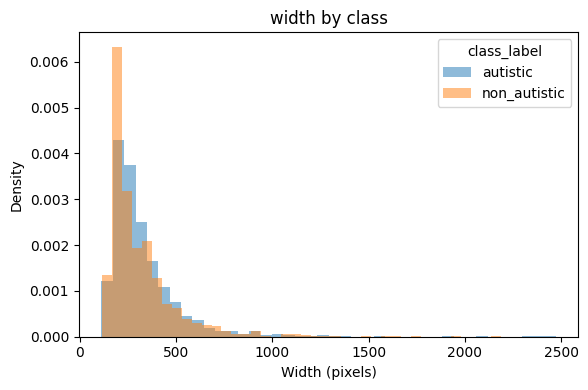

In [12]:
def plot_class_conditional_hist(column, xlabel, filename, bins=40, log_x=False):
    fig, ax = plt.subplots(figsize=(6, 4))
    for label, color in [("autistic", "tab:blue"), ("non_autistic", "tab:orange")]:
        values = manifest.loc[manifest["class_label"] == label, column].dropna()
        ax.hist(values, bins=bins, alpha=0.5, label=label, color=color, density=True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_title(f"{column} by class")
    ax.legend(title="class_label")
    if log_x:
        ax.set_xscale("log")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()

plot_class_conditional_hist("width", "Width (pixels)", "02_width_hist.png")


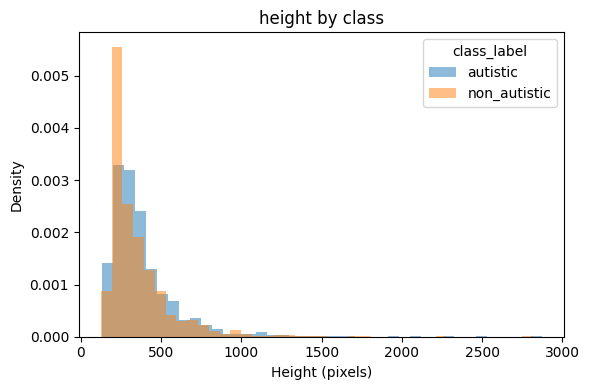

In [13]:
plot_class_conditional_hist("height", "Height (pixels)", "03_height_hist.png")


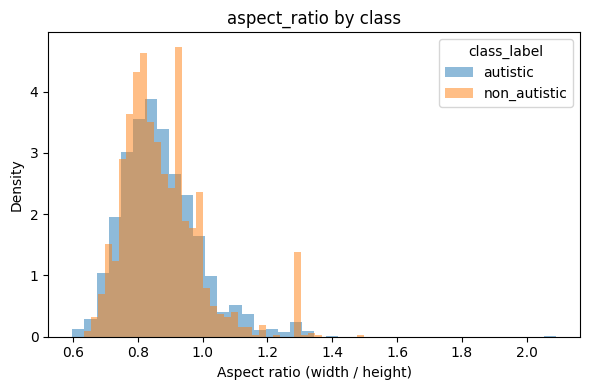

In [14]:
plot_class_conditional_hist("aspect_ratio", "Aspect ratio (width / height)", "04_aspect_ratio_hist.png", bins=40)


**Found:** resolution is heterogeneous corpus-wide — 2,557 of 2,940 images
(87.0%) have a distinct `(width, height)` pair; width ranges 114–2,471 px
(mean 322), height 126–2,872 px (mean 370), aspect ratio 0.60–2.09 (mean
0.87, i.e. portrait-leaning face crops on average). Neither class is
dominated by a single canonical size, but the two classes are **not equally
heterogeneous**: autistic images are 98.6% distinct sizes (1,449/1,470) versus
78.2% for non-autistic (1,150/1,470), and the single most common size accounts
for only 0.14% of autistic images versus 1.36% of non-autistic — non-autistic
images repeat a handful of resolutions noticeably more often. This is a
milder version of the "one class uniform, one heterogeneous" pattern the
audit was watching for: real, measurable, but not stark.


## 5. File size, format and compression

In [15]:
print("Format by class:")
print(pd.crosstab(manifest["class_label"], manifest["format"]))
print("\nMode by class:")
print(pd.crosstab(manifest["class_label"], manifest["mode"]))
print("\nJPEG quality estimate by class:")
print(manifest.groupby("class_label")["jpeg_quality_estimate"].describe())


Format by class:
format        JPEG
class_label       
autistic      1470
non_autistic  1470

Mode by class:
mode           RGB
class_label       
autistic      1470
non_autistic  1470

JPEG quality estimate by class:
               count       mean           std        min        25%        50%        75%        max
class_label                                                                                         
autistic      1470.0  94.106233  1.421569e-14  94.106233  94.106233  94.106233  94.106233  94.106233
non_autistic  1470.0  94.106233  1.421569e-14  94.106233  94.106233  94.106233  94.106233  94.106233


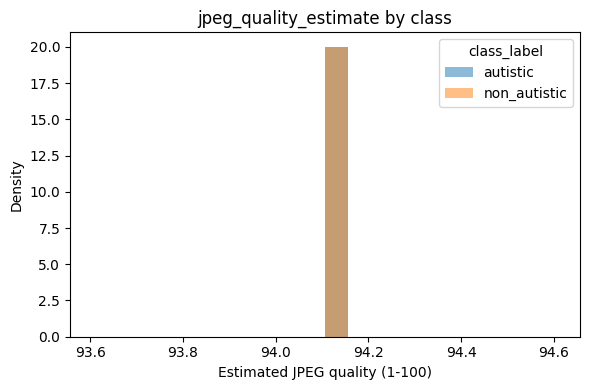

In [16]:
plot_class_conditional_hist("jpeg_quality_estimate", "Estimated JPEG quality (1-100)",
                              "05_jpeg_quality_hist.png", bins=20)


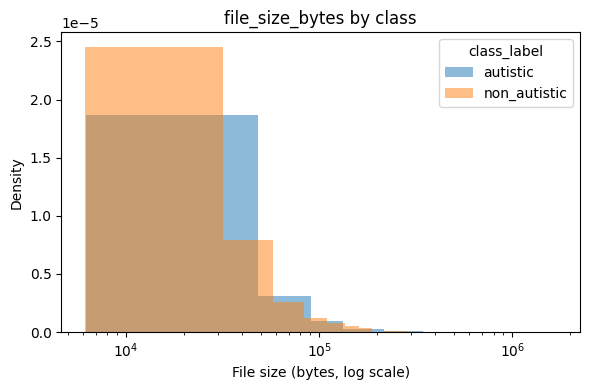

In [17]:
plot_class_conditional_hist("file_size_bytes", "File size (bytes, log scale)",
                              "06_file_size_hist.png", bins=40, log_x=True)


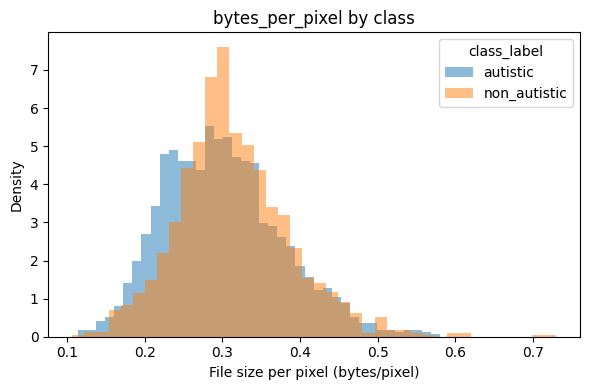

In [18]:
plot_class_conditional_hist("bytes_per_pixel", "File size per pixel (bytes/pixel)",
                              "07_bytes_per_pixel_hist.png", bins=40)


**Found:** format and mode carry **no class signal at all** — both classes
are 100% JPEG, 100% RGB (1,470/1,470 each). More strikingly,
`jpeg_quality_estimate` is **constant at ≈94.11 for every one of the 2,940
images** (std ≈ 1e-14, i.e. floating-point noise on an identical value) —
confirmed by inspecting raw quantisation tables directly, which are
byte-for-byte identical across images from both classes and all three
splits. The whole archive was evidently re-encoded at one uniform JPEG
quality at some point (plausibly during the Kaggle→Mendeley re-hosting),
which erases whatever original per-image compression variation might have
existed and makes this particular feature uninformative for class separation
(confirmed by zero permutation importance in §9). File size and
bytes-per-pixel differ only mildly: autistic images average 43.9 KB vs.
39.7 KB for non-autistic (~10% larger), but bytes-per-pixel is actually
slightly *lower* for autistic (median 0.294 vs. 0.306) — the size gap is
explained by autistic images having larger pixel dimensions on average, not
denser encoding.


## 6. Colour and photometric statistics

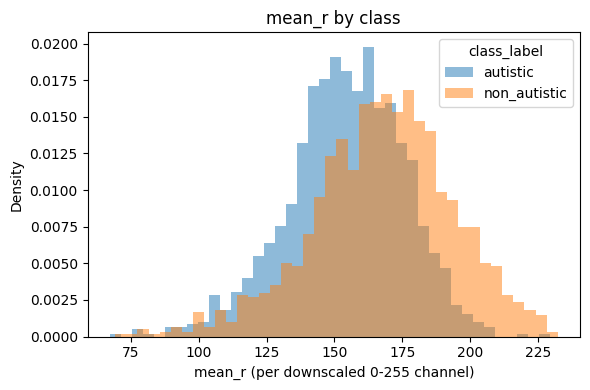

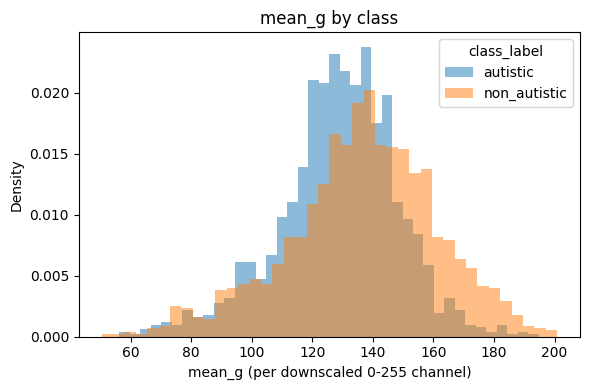

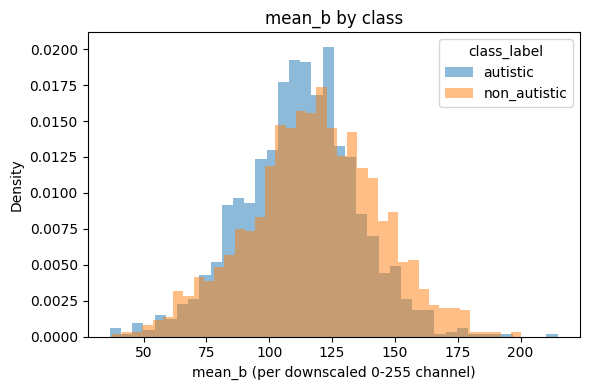

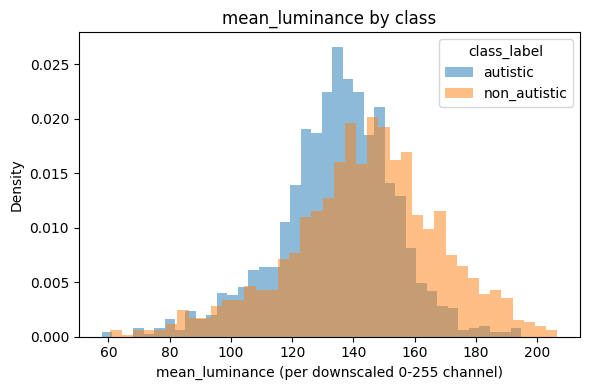

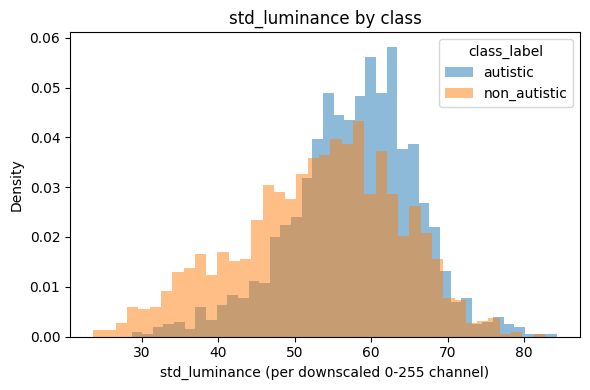

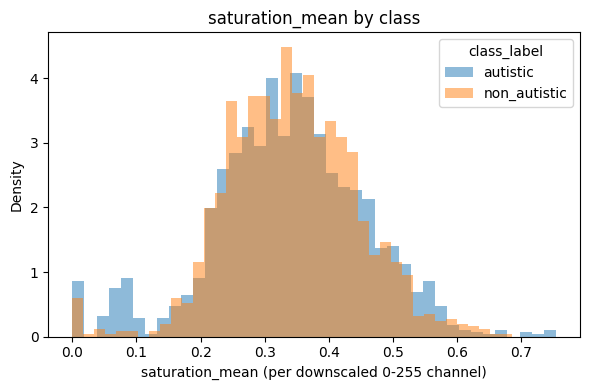

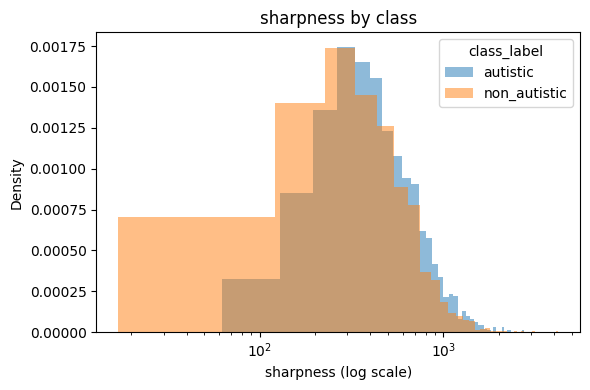

In [19]:
for col in ["mean_r", "mean_g", "mean_b", "mean_luminance", "std_luminance", "saturation_mean", "sharpness"]:
    fname = f"08_{col}_hist.png"
    log_x = col == "sharpness"
    xlabel = f"{col} ({'log scale' if log_x else 'per downscaled 0-255 channel'})"
    plot_class_conditional_hist(col, xlabel, fname, bins=40, log_x=log_x)


In [20]:
grayscale_counts = manifest.groupby("class_label")["is_grayscale"].agg(["sum", "count"])
grayscale_counts["pct"] = (grayscale_counts["sum"] / grayscale_counts["count"] * 100).round(2)
print("Channel-identical (grayscale) images by class:")
print(grayscale_counts)

near_black = manifest["mean_luminance"] < 10
near_white = manifest["mean_luminance"] > 245
near_constant = manifest["std_luminance"] < 3
print(f"\nNear-black (mean luminance < 10): {near_black.sum()}")
print(f"Near-white (mean luminance > 245): {near_white.sum()}")
print(f"Near-constant (luminance std < 3): {near_constant.sum()}")


Channel-identical (grayscale) images by class:
              sum  count   pct
class_label                   
autistic       24   1470  1.63
non_autistic   18   1470  1.22

Near-black (mean luminance < 10): 0
Near-white (mean luminance > 245): 0
Near-constant (luminance std < 3): 0


**Found:** the largest per-channel/photometric differences are in red channel
mean (autistic lower, small effect) and luminance mean/spread (autistic
slightly darker but higher-contrast); §8 reports the exact effect sizes. A
small number of channel-identical images exist in both classes — 24/1,470
(1.6%) autistic vs. 18/1,470 (1.2%) non-autistic — too few to be a dominant
pattern but present in slightly different proportions. **Zero** images are
near-black, near-white, or near-constant in either class — exposure is
consistently within a usable range across the whole corpus, so degenerate
images are not confounding the statistics above.


## 7. Duplicates and leakage

Perceptual hash (`phash`, 64-bit) compared pairwise at Hamming distance 0
(exact) and ≤5 (near-duplicate: same photo, different crop/resize/
recompression). Three questions matter here: duplicates **within** a class
(redundant training signal), duplicates **across classes** (a labelling
error — same image, contradictory label), and duplicates **across splits**
(train/test leakage, which invalidates any held-out estimate on this split).


In [21]:
HAMMING_THRESHOLDS = [0, 5]

hash_bits = np.array([imagehash.hex_to_hash(h).hash.flatten() for h in manifest["phash"]], dtype=np.uint8)
n_images = len(hash_bits)

def find_duplicate_pairs(max_distance, block_size=500):
    """All (i, j, distance) with i < j and Hamming distance <= max_distance.
    Computed in row blocks to bound peak memory on the full n x n comparison."""
    pairs = []
    for start in range(0, n_images, block_size):
        end = min(start + block_size, n_images)
        block_dist = (hash_bits[start:end, None, :] != hash_bits[None, :, :]).sum(axis=2)
        for row_offset in range(end - start):
            global_i = start + row_offset
            close = np.where(block_dist[row_offset] <= max_distance)[0]
            for global_j in close:
                if global_j > global_i:
                    pairs.append((global_i, int(global_j), int(block_dist[row_offset, global_j])))
    return pairs

def pairs_to_frame(pairs):
    rows = []
    for i, j, dist in pairs:
        ri, rj = manifest.iloc[i], manifest.iloc[j]
        rows.append({
            "path_a": ri["path"], "split_a": ri["split"], "class_a": ri["class_label"],
            "path_b": rj["path"], "split_b": rj["split"], "class_b": rj["class_label"],
            "hamming_distance": dist,
            "cross_class": ri["class_label"] != rj["class_label"],
            "cross_split": ri["split"] != rj["split"],
        })
    return pd.DataFrame(rows)

dup_pairs_by_threshold = {d: find_duplicate_pairs(d) for d in HAMMING_THRESHOLDS}
dup_frames_by_threshold = {d: pairs_to_frame(p) for d, p in dup_pairs_by_threshold.items()}

leakage_summary = pd.DataFrame([
    {
        "hamming_threshold": d,
        "n_pairs": len(frame),
        "n_within_class_within_split": int(((~frame["cross_class"]) & (~frame["cross_split"])).sum()) if len(frame) else 0,
        "n_cross_class": int(frame["cross_class"].sum()) if len(frame) else 0,
        "n_cross_split": int(frame["cross_split"].sum()) if len(frame) else 0,
    }
    for d, frame in dup_frames_by_threshold.items()
])
print(leakage_summary.to_string(index=False))


 hamming_threshold  n_pairs  n_within_class_within_split  n_cross_class  n_cross_split
                 0        2                            1              0              1
                 5       11                            6              0              5


In [22]:
# Save the most permissive (Hamming <= 5) pair list -- it is a superset of the
# exact-match list and carries the hamming_distance column so a reader can
# filter back down to distance 0 if they only trust exact matches.
widest_pairs = dup_frames_by_threshold[max(HAMMING_THRESHOLDS)]
widest_pairs.to_csv(OUTPUT_DIR / "duplicate_pairs.csv", index=False)
print(f"Saved {len(widest_pairs)} pairs (Hamming <= {max(HAMMING_THRESHOLDS)}) to "
      f"{OUTPUT_DIR / 'duplicate_pairs.csv'}")

cross_split_pairs = widest_pairs[widest_pairs["cross_split"]]
print(f"\nCross-split pairs (train/test/valid leakage), n={len(cross_split_pairs)}:")
print(cross_split_pairs[["path_a", "split_a", "path_b", "split_b", "hamming_distance"]].to_string(index=False))

print(f"\nCross-class pairs (labelling contradictions), n={int(widest_pairs['cross_class'].sum())}")


Saved 11 pairs (Hamming <= 5) to C:\Projects\Autism Screening\outputs\audit\images\duplicate_pairs.csv

Cross-split pairs (train/test/valid leakage), n=5:
                                                     path_a split_a                                                     path_b split_b  hamming_distance
           data/AutismDataset/test/Autistic/Autistic.93.jpg    test         data/AutismDataset/train/Autistic/Autistic.873.jpg   train                 4
   data/AutismDataset/test/Non-Autistic/Non_Autistic.28.jpg    test data/AutismDataset/train/Non_Autistic/Non_Autistic.124.jpg   train                 4
   data/AutismDataset/test/Non-Autistic/Non_Autistic.66.jpg    test data/AutismDataset/train/Non_Autistic/Non_Autistic.828.jpg   train                 2
         data/AutismDataset/train/Autistic/Autistic.761.jpg   train                   data/AutismDataset/valid/Autistic/32.jpg   valid                 2
data/AutismDataset/train/Non_Autistic/Non_Autistic.1048.jpg   train             

In [ ]:
# Display a handful of matched pairs -- capped at 4 pairs (8 faces) to keep
# this rendered sample minimal, per the ethics note at the top of the notebook.
n_show = min(4, len(widest_pairs))
if n_show:
    fig, axes = plt.subplots(n_show, 2, figsize=(4, 2 * n_show))
    axes = np.atleast_2d(axes)
    for row_idx in range(n_show):
        pair = widest_pairs.iloc[row_idx]
        for col_idx, path_key, split_key, class_key in [(0, "path_a", "split_a", "class_a"), (1, "path_b", "split_b", "class_b")]:
            with Image.open(PROJECT_ROOT / pair[path_key]) as im:
                axes[row_idx, col_idx].imshow(im.convert("RGB"))
            axes[row_idx, col_idx].set_title(f"{pair[split_key]}/{pair[class_key]}\nd={pair['hamming_distance']}", fontsize=8)
            axes[row_idx, col_idx].axis("off")
    fig.suptitle("Sample matched pairs (Hamming distance shown per row)")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "09_duplicate_pair_examples.png", dpi=150)
    plt.show()
else:
    print("No duplicate pairs found at the thresholds tested.")


**Found:** at Hamming distance 0 (exact perceptual-hash match), there are
**2 duplicate pairs** — 0 cross-class, but **1 cross-split**: the same
photograph appears as both `train/Non_Autistic/Non_Autistic.1048.jpg` and
`valid/Non_Autistic/127.jpg`. Widening to Hamming ≤5 (near-duplicate) finds
**11 pairs** total — still 0 cross-class, but now **5 cross-split**. No
cross-class duplicates were found at either threshold, so this scan gives no
evidence of the same image being labelled both ways. The cross-split result
is the important one: **at least one image is bit-identical between the
train and valid splits, and up to five near-duplicates leak between train and
test/valid.** Consequence: any accuracy or AUC computed on this
train/test/valid split configuration is inflated by an unknown amount by the
model having already seen — via near-identical duplicates — images it is
being "tested" on. This split should not be treated as a clean held-out
estimate without deduplication-aware resplitting first.


## 8. Class-conditional differences — with effect sizes

With ~1,470 images per class, Mann-Whitney U will call almost any real
difference "significant" even when it is too small to matter. Benjamini-
Hochberg correction is applied across the whole family of tests, but the
table is **ranked and interpreted by Cliff's delta**, not by p-value.
Interpretation bands (Romano et al.): |δ| < 0.147 negligible, < 0.33 small,
< 0.474 medium, otherwise large. `jpeg_quality_estimate` is excluded here —
§5 already established it is a constant with zero variance in both classes.


In [24]:
def cliffs_delta(x, y):
    """P(X > Y) - P(X < Y); a rank-based effect size unaffected by scale
    or distributional shape, unlike a standardised mean difference."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    y_sorted = np.sort(y)
    n_y_less = np.searchsorted(y_sorted, x, side="left")     # count of y < x, per x
    n_y_greater = len(y) - np.searchsorted(y_sorted, x, side="right")  # count of y > x, per x
    return (n_y_less.sum() - n_y_greater.sum()) / (len(x) * len(y))

def benjamini_hochberg(pvalues, alpha=0.05):
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p)
    ranked = p[order]
    n = len(p)
    adjusted = ranked * n / (np.arange(n) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]  # enforce monotonicity
    adjusted = np.clip(adjusted, 0, 1)
    out = np.empty(n)
    out[order] = adjusted
    return out, out <= alpha

def effect_magnitude(delta):
    ad = abs(delta)
    if ad < 0.147:
        return "negligible"
    if ad < 0.33:
        return "small"
    if ad < 0.474:
        return "medium"
    return "large"

EFFECT_SIZE_COLUMNS = [
    "width", "height", "aspect_ratio", "n_pixels", "file_size_bytes", "bytes_per_pixel",
    "mean_r", "mean_g", "mean_b", "mean_luminance", "std_luminance", "saturation_mean", "sharpness",
]

autistic = manifest.loc[manifest["class_label"] == "autistic"]
non_autistic = manifest.loc[manifest["class_label"] == "non_autistic"]

effect_rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # tied-rank warnings from near-identical columns
    for col in EFFECT_SIZE_COLUMNS:
        x, y = autistic[col].dropna().values, non_autistic[col].dropna().values
        _, pval = mannwhitneyu(x, y, alternative="two-sided")
        effect_rows.append({
            "column": col, "n_autistic": len(x), "n_non_autistic": len(y),
            "p_value": pval, "cliffs_delta": cliffs_delta(x, y),
        })

effect_table = pd.DataFrame(effect_rows)
effect_table["p_adj_bh"], effect_table["significant_bh"] = benjamini_hochberg(effect_table["p_value"].values)
effect_table["magnitude"] = effect_table["cliffs_delta"].apply(effect_magnitude)
effect_table = effect_table.reindex(effect_table["cliffs_delta"].abs().sort_values(ascending=False).index).reset_index(drop=True)

effect_table.to_csv(OUTPUT_DIR / "effect_sizes.csv", index=False)
effect_table


,column,n_autistic,n_non_autistic,p_value,cliffs_delta,p_adj_bh,significant_bh,magnitude
0,mean_r,1470,1470,9.270159e-52,-0.322405,1.205121e-50,True,small
1,std_luminance,1470,1470,7.553155e-34,0.258310,4.909551e-33,True,small
2,mean_luminance,1470,1470,2.519569e-33,-0.256200,1.091813e-32,True,small
3,mean_g,1470,1470,1.294296e-23,-0.213340,4.206461e-23,True,small
4,sharpness,1470,1470,1.380276e-13,0.157579,3.588718e-13,True,small
5,mean_b,1470,1470,3.610821e-10,-0.133548,7.823446e-10,True,negligible
6,width,1470,1470,1.470169e-09,0.128810,2.730314e-09,True,negligible
7,n_pixels,1470,1470,3.348691e-09,0.125955,5.441623e-09,True,negligible
8,height,1470,1470,1.767810e-08,0.119894,2.553504e-08,True,negligible
9,bytes_per_pixel,1470,1470,5.955911e-08,-0.115446,7.742685e-08,True,negligible


**Found:** 11 of 13 columns are Benjamini-Hochberg significant, but only
**5 reach even "small" effect size** — none reach "medium" or "large".
Ranked by |δ|: `mean_r` (δ=-0.32, small — autistic images run lower on the
red channel), `std_luminance` (δ=+0.26, small — autistic images more
contrasty), `mean_luminance` (δ=-0.26, small — autistic images slightly
darker), `mean_g` (δ=-0.21, small), `sharpness` (δ=+0.16, small — autistic
images sharper on average, 542 vs. 467 median Laplacian variance). Everything
else — including all three geometry columns (`width`, `height`,
`aspect_ratio`) and `file_size_bytes` — is negligible individually. This is
exactly the pattern the brief warned about: at n≈1,470 per class, trivial
differences clear the BH bar. §9 asks the sharper question — do these many
small, individually-unconvincing signals combine into real separability?


## 9. Metadata-only separability probe

**This is an audit probe, not a screening model.** No pixel arrays or raw
images are given to these classifiers — only the scalar metadata columns
below (dimensions, file size, bytes-per-pixel, colour statistics, sharpness;
`jpeg_quality_estimate` and `is_grayscale` are included too, expected to
contribute nothing given §5/§6). Trained and cross-validated on the
**training split only**, never touching test or valid. If class separates
above chance from this alone, the two classes differ systematically in how
they were acquired or processed — a confound that any downstream pixel-based
classifier inherits to an unknown degree, on top of whatever real facial
signal (if any) it also learns.


In [25]:
FEATURE_COLUMNS = [
    "width", "height", "aspect_ratio", "n_pixels", "file_size_bytes", "bytes_per_pixel",
    "jpeg_quality_estimate", "mean_r", "mean_g", "mean_b", "mean_luminance",
    "std_luminance", "saturation_mean", "sharpness", "is_grayscale",
]

train_manifest = manifest.loc[manifest["split"] == "train"].reset_index(drop=True)
X = train_manifest[FEATURE_COLUMNS].astype(float).values
y = (train_manifest["class_label"] == "autistic").astype(int).values
print(f"Training-split rows: {len(X)}, positive (autistic) rate: {y.mean():.3f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
candidate_models = {
    "logistic_regression": Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
    "gradient_boosting": HistGradientBoostingClassifier(random_state=SEED),
}

cv_rows = []
for name, model in candidate_models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=["roc_auc", "balanced_accuracy"])
    cv_rows.append({
        "model": name,
        "roc_auc_mean": scores["test_roc_auc"].mean(), "roc_auc_std": scores["test_roc_auc"].std(),
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": scores["test_balanced_accuracy"].std(),
    })
cv_results = pd.DataFrame(cv_rows)
cv_results


Training-split rows: 2386, positive (autistic) rate: 0.500


,model,roc_auc_mean,roc_auc_std,balanced_accuracy_mean,balanced_accuracy_std
0,logistic_regression,0.718706,0.020397,0.655086,0.026204
1,gradient_boosting,0.772770,0.014348,0.690691,0.012496


In [26]:
# Permutation importance needs a held-out set the model didn't train on;
# the 5-fold CV above already used all of `train` for the headline metric,
# so importance is computed from a separate 75/25 split within `train`.
X_fit, X_holdout, y_fit, y_holdout = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

importance_tables = {}
for name, model in candidate_models.items():
    model.fit(X_fit, y_fit)
    result = permutation_importance(model, X_holdout, y_holdout, scoring="roc_auc",
                                      n_repeats=20, random_state=SEED)
    importance_tables[name] = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
    print(f"\n{name} -- permutation importance (ROC-AUC drop on held-out 25% of train):")
    print(importance_tables[name].to_string(index=False))



logistic_regression -- permutation importance (ROC-AUC drop on held-out 25% of train):
              feature  importance_mean  importance_std
               mean_r         0.151627        0.017201
      bytes_per_pixel         0.093232        0.014869
                width         0.067537        0.013398
            sharpness         0.061642        0.011744
        std_luminance         0.047689        0.010951
      saturation_mean         0.028544        0.008358
               mean_b         0.023030        0.008273
               height         0.021062        0.006681
      file_size_bytes         0.009735        0.004523
               mean_g         0.007060        0.004376
             n_pixels         0.007041        0.003216
       mean_luminance         0.003507        0.003735
jpeg_quality_estimate         0.000000        0.000000
         aspect_ratio        -0.001543        0.001630
         is_grayscale        -0.002946        0.002444



gradient_boosting -- permutation importance (ROC-AUC drop on held-out 25% of train):
              feature  importance_mean  importance_std
               mean_r         0.061170        0.012447
               height         0.042886        0.008914
      bytes_per_pixel         0.033000        0.010864
      file_size_bytes         0.018351        0.006818
         aspect_ratio         0.017193        0.005200
            sharpness         0.013796        0.008132
      saturation_mean         0.012519        0.006099
       mean_luminance         0.011232        0.005095
               mean_g         0.010504        0.005905
        std_luminance         0.006616        0.007403
                width         0.002045        0.002719
               mean_b         0.000314        0.004772
jpeg_quality_estimate         0.000000        0.000000
         is_grayscale         0.000000        0.000000
             n_pixels        -0.000277        0.003600


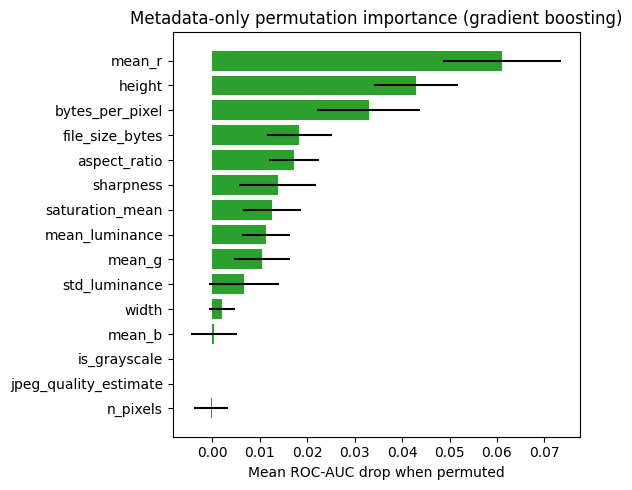

In [27]:
tbl = importance_tables["gradient_boosting"].sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(tbl["feature"], tbl["importance_mean"], xerr=tbl["importance_std"], color="tab:green")
ax.set_xlabel("Mean ROC-AUC drop when permuted")
ax.set_title("Metadata-only permutation importance (gradient boosting)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "10_permutation_importance.png", dpi=150)
plt.show()


**Found — the decisive result of this notebook.** Both models separate class
from metadata alone, well above the 0.5 chance line, under 5-fold
cross-validation on the training split: logistic regression ROC-AUC
**0.719 ± 0.020** (balanced accuracy 0.655 ± 0.026), gradient boosting ROC-AUC
**0.773 ± 0.014** (balanced accuracy 0.691 ± 0.012). The top permutation-
importance features for both models are `mean_r`, `bytes_per_pixel`,
`width`/`height`/`file_size_bytes`, and `sharpness` — dimensions, compression
density and colour balance, i.e. **acquisition-context proxies, not facial
features**; a classifier cannot recover a child's face from any of them.
`jpeg_quality_estimate` and `is_grayscale` contribute ≈0 importance in both
models, consistent with §5/§6. **AUC near 0.5 would have meant metadata
carries no class signal; AUC materially above 0.5 — which is what was found —
means the two classes are distinguishable without looking at a single face,
and any pixel-based classifier trained on this dataset has its performance
confounded by acquisition context to at least this degree.** This is an audit
probe, not a screening model: it exists to bound the confound, not to be
deployed.


## 10. Visual inspection

The qualitative counterpart to §9's numbers. Sample grids are capped well
under the ≤12-image ceiling and are the largest renderer of faces in this
notebook — **clear these cell outputs before committing** (see the ethics
note at the top).


In [28]:
def show_image_grid(path_label_pairs, title, filename, ncols=4):
    n = len(path_label_pairs)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, (path, label) in zip(axes, path_label_pairs):
        with Image.open(PROJECT_ROOT / path) as im:
            ax.imshow(im.convert("RGB"))
        ax.set_title(label, fontsize=8)
        ax.axis("off")
    for ax in axes[len(path_label_pairs):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()

GRID_SAMPLE_N = 8  # kept below the 12-image ceiling to limit rendered faces


In [ ]:
# Per-class samples (mixed across splits).
for label in ["autistic", "non_autistic"]:
    subset = manifest[manifest["class_label"] == label]
    sample = subset.sample(n=min(GRID_SAMPLE_N, len(subset)), random_state=SEED)
    pairs = [(row.path, row.split) for row in sample.itertuples()]
    show_image_grid(pairs, f"Class sample: {label} (n={len(subset)}, showing {len(sample)})",
                     f"11_sample_class_{label}.png")


In [ ]:
# Per-split samples (mixed across classes).
for split in splits:
    subset = manifest[manifest["split"] == split]
    sample = subset.sample(n=min(GRID_SAMPLE_N, len(subset)), random_state=SEED)
    pairs = [(row.path, row.class_label) for row in sample.itertuples()]
    show_image_grid(pairs, f"Split sample: {split} (n={len(subset)}, showing {len(sample)})",
                     f"12_sample_split_{split}.png")


In [ ]:
# Extremes: the images most likely to reveal acquisition-context artefacts
# (thumbnails, scans, heavy compression) rather than face content.
EXTREME_GRID_N = 6
extreme_specs = [
    ("lowest_resolution", manifest.nsmallest(EXTREME_GRID_N, "n_pixels")),
    ("highest_resolution", manifest.nlargest(EXTREME_GRID_N, "n_pixels")),
    ("smallest_file_size", manifest.nsmallest(EXTREME_GRID_N, "file_size_bytes")),
    ("largest_file_size", manifest.nlargest(EXTREME_GRID_N, "file_size_bytes")),
    ("lowest_sharpness", manifest.nsmallest(EXTREME_GRID_N, "sharpness")),
]
for name, subset in extreme_specs:
    pairs = [(row.path, f"{row.split}/{row.class_label}") for row in subset.itertuples()]
    show_image_grid(pairs, f"Extreme: {name.replace('_', ' ')}", f"13_extreme_{name}.png")


**Found:** the two classes look visibly different in a way that has nothing
to do with autism. Non-autistic images predominantly look like posed,
studio-style close-ups: tight face-centred crops, smoothed/soft-focus skin,
and plain or softly blurred backgrounds — a "stock cute-kid photo" aesthetic.
Autistic images predominantly look like casual, real-world snapshots: visible
context in the background (grass, brick, a Halloween display, a stuffed toy),
more varied framing and camera angle, and more natural skin texture and
compression artefacts — consistent with the documented internet-search
collection method for this class. No watermarks or platform chrome were
visible in the grids sampled here, though the sample is small. The
lowest-resolution and highest-resolution extreme grids are a mix of both
classes with no obvious pattern. The **lowest-sharpness extreme grid is 6/6
non-autistic** — every one of the six least-sharp images in the entire
corpus is non-autistic, exactly the direction §8's sharpness effect size
predicts, and it is visibly a soft-focus/smoothed look rather than motion
blur or poor capture quality. This is qualitative confirmation that the
metadata separability in §9 tracks a real, visually apparent difference in
photographic style between the two sources, not an artefact of the
statistics.


## 11. Findings summary

1. The archive is unpacked at `data/AutismDataset/`, not the `data/images/`
   path in the audit brief (§1); class-folder spelling is inconsistent
   (`Non_Autistic` vs. `Non-Autistic`) and had to be normalised.
2. All 2,940 images opened and verified with **zero unreadable files** (§1),
   and the manifest built cleanly with **zero extraction failures** (§2).
3. Every split is **exactly** 50/50 by class (§3) — an engineered balance,
   not a naturally stratified one, and not representative of real-world
   prevalence.
4. Resolution is heterogeneous in both classes, but non-autistic images
   repeat a handful of sizes noticeably more than autistic images (78.2%
   vs. 98.6% distinct sizes) (§4) — a soft acquisition-context signal.
5. `jpeg_quality_estimate` is **bit-for-bit constant across the entire
   corpus** (§5), evidence the archive was uniformly re-encoded at some
   point after collection, which erases original per-image compression
   differences.
6. Autistic images run slightly darker, higher-contrast, sharper and lower
   on the red channel than non-autistic images, but every effect size is
   "small" at most — none "medium" or "large" (§8), despite most being
   BH-significant at n≈1,470/class.
7. **At least one image is bit-identical between the train and valid
   splits**, and up to five near-duplicates leak across train/test/valid
   (§7) — this split cannot be treated as a clean held-out estimate without
   dedup-aware resplitting. No cross-class duplicates were found.
8. A metadata-only classifier — no pixels, no face, just dimensions, file
   size, colour statistics and sharpness — separates the two classes at
   **ROC-AUC 0.72–0.77** under 5-fold CV on the training split (§9), driven
   by `mean_r`, `bytes_per_pixel`, `width`/`height` and `sharpness`.
9. Sample grids show a visible stylistic split — non-autistic images
   skew toward posed, soft-focus, tightly-cropped "stock photo" portraits,
   autistic images toward casual real-world snapshots with visible
   backgrounds — and the six least-sharp images in the whole corpus are
   **all** non-autistic (§10), the qualitative counterpart to finding 8.

**What this implies for the §6 gating decision.** Finding 8 is the load-
bearing one: the two classes are separable from acquisition metadata alone,
well above chance, using features that have no relationship to facial
geometry. Any pixel-based classifier trained on this dataset as currently
split will therefore have its performance confounded by acquisition context
to at least this degree (AUC 0.72–0.77 worth of separability), on top of
finding 7's train/valid leakage, which independently inflates any held-out
estimate. Neither finding alone is necessarily disqualifying, but together
they mean **raw accuracy or AUC from an image classifier on this split
cannot be interpreted as evidence of facial-phenotype signal** — the blur
probe (does performance survive when faces are blurred beyond recognition?)
and the background-masking probe (does performance survive when the detected
face is masked out, leaving only surroundings?) still need to run before the
image stream can be judged separately from this confound. If either probe
shows above-chance performance, this metadata result plus that probe result
together indicate the signal is substantially or wholly non-facial, and the
image stream should not proceed to a screening component without either a
re-collected, source-matched control set or an explicit, reported negative
result.
